# 01 - Exploratory Data Analysis: Albania (PISA 2009–2022)

**Project:** Predicting Albanian Student Low-Proficiency Risk - A Comparative ML Framework

This notebook explores the Albanian longitudinal dataset (27,042 students, five cycles). All statistics use PISA sampling weights (`W_FSTUWT`). Logic lives in `src/`; this notebook is the narrative layer.

**Key question addressed here:** How did Albania's low-proficiency risk evolve, and what does the dramatic 2018→2022 reversal look like in the data?

## Methods & formulas (reference)

Every statistic below is **survey-weighted**, and every inferential one carries a
**design-based** standard error. The machinery used throughout the project:

**Weighted mean / proportion.** For values $x_i$ with final student weights
$w_i=$ `W_FSTUWT`,
$$\bar x_w=\frac{\sum_i w_i x_i}{\sum_i w_i},\qquad
\hat p_w=\frac{\sum_i w_i\,\mathbb{1}[x_i=1]}{\sum_i w_i}.$$

**Plausible values (PVs).** Achievement is not observed but *drawn*: PISA ships
$L=10$ plausible values per student (imputations from the item-response
posterior). A statistic is computed on each PV and combined (Rubin, below);
collapsing the PVs to their mean understates uncertainty.

**BRR (Balanced Repeated Replication).** The *sampling* variance uses $R=80$ Fay
replicate weights $w_i^{(r)}$:
$$\operatorname{Var}_{\text{smp}}(\hat\theta)=\frac{1}{R\,(1-k)^2}
\sum_{r=1}^{R}\big(\hat\theta^{(r)}-\hat\theta\big)^2,\qquad k=0.5\ (\text{Fay}).$$

**Rubin's rules (combine PVs).** With per-PV estimate $\hat\theta_\ell$ and its
sampling variance $U_\ell$,
$$\bar\theta=\tfrac1L\!\sum_\ell\hat\theta_\ell,\quad
\bar U=\tfrac1L\!\sum_\ell U_\ell,\quad
B=\tfrac{1}{L-1}\!\sum_\ell(\hat\theta_\ell-\bar\theta)^2,$$
$$\operatorname{Var}(\bar\theta)=\bar U+\Big(1+\tfrac1L\Big)B,\qquad
\text{FMI}\approx\frac{(1+1/L)\,B}{\operatorname{Var}(\bar\theta)}.$$
$B$ is the between-PV (imputation) variance; **FMI** is the share of total
variance due to the PV draw.

**Effect sizes.** Weighted **Cohen's $d$** (at-risk vs proficient on a feature):
$d=\dfrac{\bar x_{w,1}-\bar x_{w,0}}{s_{w,\text{pool}}}$.
**Cramér's $V$** for an $r\times c$ table: $V=\sqrt{\dfrac{\chi^2/n}{\min(r-1,c-1)}}$,
with $\chi^2$ on **normalized** weights (rescaled to sample $n$) so
population-scale weights don't inflate it.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from src.features.target import add_all_targets
from src.data.weights import weighted_mean, weighted_proportion, weighted_std

df = add_all_targets(pd.read_parquet('../data/processed/albania_longitudinal.parquet'))
print('Rows:', len(df), '| Cycles:', sorted(df.CYCLE.unique()))
df[['CYCLE','MATH_PV_MEAN','ESCS','HOMEPOS','AT_RISK_MATH','W_FSTUWT']].head()

2026-07-05 08:55:28 [info     ] Point target added             at_risk_rate=0.602 domain=math threshold=420.07


2026-07-05 08:55:28 [info     ] Point target added             at_risk_rate=0.577 domain=reading threshold=407.47


2026-07-05 08:55:29 [info     ] Point target added             at_risk_rate=0.54 domain=science threshold=409.54


Rows: 27042 | Cycles: [np.int64(2009), np.int64(2012), np.int64(2015), np.int64(2018), np.int64(2022)]


,CYCLE,MATH_PV_MEAN,ESCS,HOMEPOS,AT_RISK_MATH,W_FSTUWT
0,2009,456.154,-1.1272,-2.8545,0,2.9443
1,2009,449.922,0.5878,-1.4413,0,2.9443
2,2009,408.796,-0.3142,-1.6609,1,2.9443
3,2009,247.242,-0.0151,-1.0950,1,2.9443
4,2009,388.154,0.9859,-0.7652,1,2.9443


## 0. Data dictionary & provenance

Before any statistic, *what are we looking at?* Each analytic variable, its plain-English meaning, the underlying PISA source item, the direction of the scale, and the cycles in which it is available for Albania. The OECD background **indices** (ESCS, HOMEPOS, BELONG, …) are standardised to an OECD mean 0 / SD 1, so a value of −0.75 means ~0.75 SD *below* the OECD student average - already an interpretation aid before we compute anything.

In [3]:
meta = {
  'MATH_PV_MEAN': ('Math score (mean of 10 plausible values)', 'PV1-10MATH', 'higher = better'),
  'AT_RISK_MATH': ('Low proficiency: math < 420 (below PISA Level 2)', 'derived', '1 = at risk'),
  'ESCS':     ('Economic, social & cultural status index', 'ESCS', 'higher = advantaged'),
  'HOMEPOS':  ('Home possessions (material + educational)', 'HOMEPOS', 'higher = more'),
  'HISCED':   ('Highest parental education (ISCED level)', 'HISCED', 'higher = more'),
  'HISEI':    ('Highest parental occupational status (ISEI)', 'HISEI', 'higher = higher status'),
  'BELONG':   ('Sense of belonging at school', 'BELONG', 'higher = more belonging'),
  'TEACHSUP': ('Perceived teacher support', 'TEACHSUP', 'higher = more support'),
  'ANXMAT':   ('Mathematics anxiety', 'ANXMAT', 'higher = more anxious'),
  'REPEAT':   ('Has repeated a grade', 'REPEAT', '1 = repeated'),
  'IMMIG':    ('Immigrant background', 'IMMIG', '1 = 1st/2nd gen'),
  'GRADE':    ('Grade relative to modal grade', 'GRADE', '0 = modal'),
  'GENDER':   ('Student gender', 'ST004D01T', 'coded 0/1'),
}
rows = []
for v,(desc,src,direction) in meta.items():
    if v not in df.columns: continue
    cyc = [int(c) for c in sorted(df.CYCLE.unique())
           if df.loc[df.CYCLE==c, v].notna().any()]
    rows.append({'variable':v,'meaning':desc,'PISA_source':src,
                 'direction':direction,'cycles_available':cyc})
pd.set_option('display.max_colwidth', 60)
pd.DataFrame(rows).set_index('variable')

,meaning,PISA_source,direction,cycles_available
variable,,,,
MATH_PV_MEAN,Math score (mean of 10 plausible values),PV1-10MATH,higher = better,"[2009, 2012, 2015, 2018, 2022]"
AT_RISK_MATH,Low proficiency: math < 420 (below PISA Level 2),derived,1 = at risk,"[2009, 2012, 2015, 2018, 2022]"
ESCS,"Economic, social & cultural status index",ESCS,higher = advantaged,"[2009, 2018, 2022]"
HOMEPOS,Home possessions (material + educational),HOMEPOS,higher = more,"[2009, 2012, 2018, 2022]"
HISCED,Highest parental education (ISCED level),HISCED,higher = more,"[2009, 2018, 2022]"
HISEI,Highest parental occupational status (ISEI),HISEI,higher = higher status,"[2009, 2018, 2022]"
BELONG,Sense of belonging at school,BELONG,higher = more belonging,"[2009, 2012, 2018, 2022]"
TEACHSUP,Perceived teacher support,TEACHSUP,higher = more support,"[2012, 2018, 2022]"
ANXMAT,Mathematics anxiety,ANXMAT,higher = more anxious,"[2012, 2022]"


**Reading:** ESCS is genuinely absent for Albania in **2012 & 2015** (an OECD data gap, not a processing bug); HOMEPOS covers all five cycles and so is the safer longitudinal SES proxy. The attitudinal indices (BELONG, TEACHSUP, ANXMAT) arrive only in the cycles that fielded the relevant questionnaire rotation.

## 0b. Survey-weighted descriptive summary (2022)

The population-level 'know your data' table for the crisis cohort: weighted mean, weighted SD, the raw range, the weighted median and - critically - **how much is missing**. High missingness on an index is itself a finding (it caps how much that feature can contribute downstream).

In [4]:
from src.data.weights import weighted_describe
feats = ['MATH_PV_MEAN','ESCS','HOMEPOS','HISCED','HISEI','BELONG',
         'TEACHSUP','ANXMAT','GRADE']
weighted_describe(df[df.CYCLE==2022], feats)

,n,pct_missing,w_mean,w_sd,min,w_median,max
feature,,,,,,,
MATH_PV_MEAN,6129,0.0,368.222,79.043,141.92,357.528,692.68
ESCS,5575,9.0,-0.751,1.087,-5.24,-0.771,2.83
HOMEPOS,5699,7.0,-0.870,1.024,-6.26,-0.886,5.35
HISCED,4603,24.9,5.604,2.511,1.00,5.000,10.00
HISEI,4773,22.1,45.168,23.454,11.01,31.720,88.96
BELONG,4743,22.6,0.253,1.052,-3.26,0.144,2.78
TEACHSUP,4002,34.7,0.408,1.245,-2.91,0.821,1.56
ANXMAT,3674,40.1,0.012,1.167,-2.39,0.051,2.63
GRADE,4734,22.8,-0.036,0.346,-3.00,0.000,2.00


**Reading:** ESCS/HOMEPOS sit well below 0 (Albania is ~0.8 SD below the OECD SES average). The attitudinal indices carry 30-40% missingness in 2022 - so any model leaning on TEACHSUP or ANXMAT is really fitting the ~60% who answered, a caveat that recurs in the modeling notebooks.

## 1. Target trajectory - the V-shaped crisis

Weighted low-proficiency rate (math score < 420, below PISA Level 2) and mean score by cycle.

In [5]:
rows = []
for c in sorted(df.CYCLE.unique()):
    s = df[df.CYCLE==c]; w = s['W_FSTUWT']
    p = weighted_proportion(s['AT_RISK_MATH'], w); n=len(s)
    rows.append({'cycle':int(c),'N':n,
                 'at_risk_%':round(p*100,1),
                 'ci95':round(1.96*np.sqrt(p*(1-p)/n)*100,2),
                 'mean_score':round(weighted_mean(s['MATH_PV_MEAN'],w),1),
                 'mean_ESCS':round(weighted_mean(s['ESCS'],w),3)})
pd.DataFrame(rows)

,cycle,N,at_risk_%,ci95,mean_score,mean_ESCS
0,2009,4596,69.3,1.33,377.5,-0.955
1,2012,4743,62.8,1.38,394.3,NaN
2,2015,5215,54.5,1.35,413.2,NaN
3,2018,6359,41.9,1.21,437.2,-0.872
4,2022,6129,75.3,1.08,368.2,-0.751


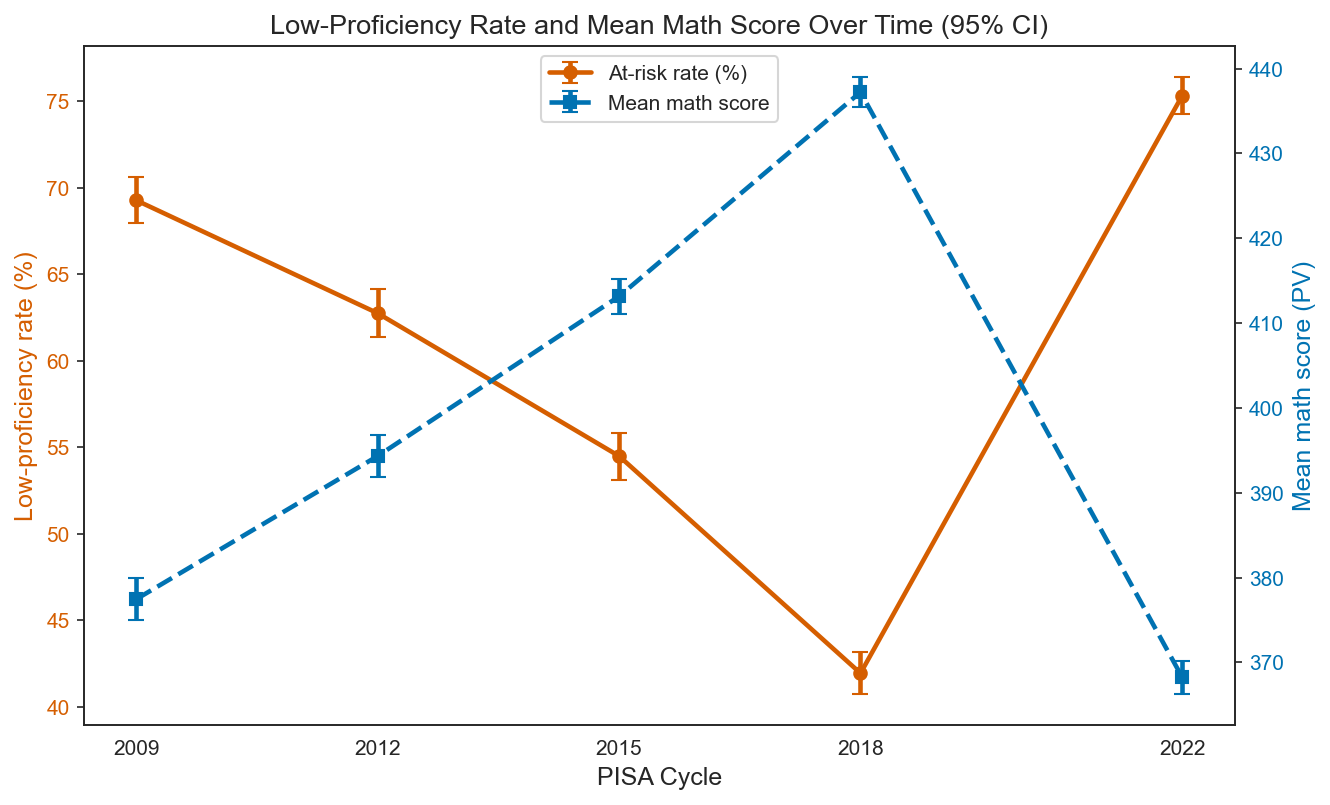

In [6]:
from src.visualization.eda import plot_atrisk_trajectory
fig = plot_atrisk_trajectory(df); plt.show()

**Reading:** Albania improved steadily 2009→2018 (low-proficiency fell ~28 pp), then reversed catastrophically in 2022 (+33 pp). This single-cycle reversal is the focus of the paper.

## 1b. Design-based standard errors (BRR + plausible values)

The CIs above use a naïve normal approximation that ignores both the PISA sampling design and the plausible-value uncertainty. The **correct** PISA standard error combines two sources (OECD Data Analysis Manual): sampling variance via **Balanced Repeated Replication** (80 Fay replicate weights, computed per PV) plus imputation variance **across the 10 plausible values** (Rubin's rules). `pv_statistic_brr` returns both, the total SE, and the **FMI** (fraction of the variance attributable to the PV draw).

> Replicate weights ship only on the SAV cycles (2015/2018/2022); the FWF cycles (2009/2012) fall back to an imputation-only SE, flagged by `BRR=False`.

In [7]:
from src.data.weights import pv_statistic_brr
rows = []
for c in sorted(df.CYCLE.unique()):
    r = pv_statistic_brr(df[df.CYCLE==c], statistic='at_risk', domain='math')
    rows.append({'cycle':int(c),
                 'at_risk':round(r['estimate'],4),
                 'SE':round(r['se'],4),
                 'ci95_low':round(r['ci95_low'],4),
                 'ci95_high':round(r['ci95_high'],4),
                 'FMI':round(r['fmi'],3),
                 'BRR':r['brr_available']})
pd.DataFrame(rows)

,cycle,at_risk,SE,ci95_low,ci95_high,FMI,BRR
0,2009,0.6773,0.0076,0.6625,0.6921,NaN,False
1,2012,0.6066,0.0051,0.5967,0.6166,NaN,False
2,2015,0.5328,0.0108,0.5118,0.5539,0.688,True
3,2018,0.4237,0.0088,0.4065,0.4410,0.790,True
4,2022,0.7394,0.0041,0.7314,0.7474,0.354,True


**Reading:** design-based SEs are small (large PISA samples) but the FMI shows the plausible values contribute a non-trivial share of the total uncertainty - collapsing them to a single mean (a common shortcut) would understate the SE. The 2009/2012 rows carry the weaker imputation-only SE, an honest caveat for any cross-cycle significance claim.

## 2. Score distributions by cycle

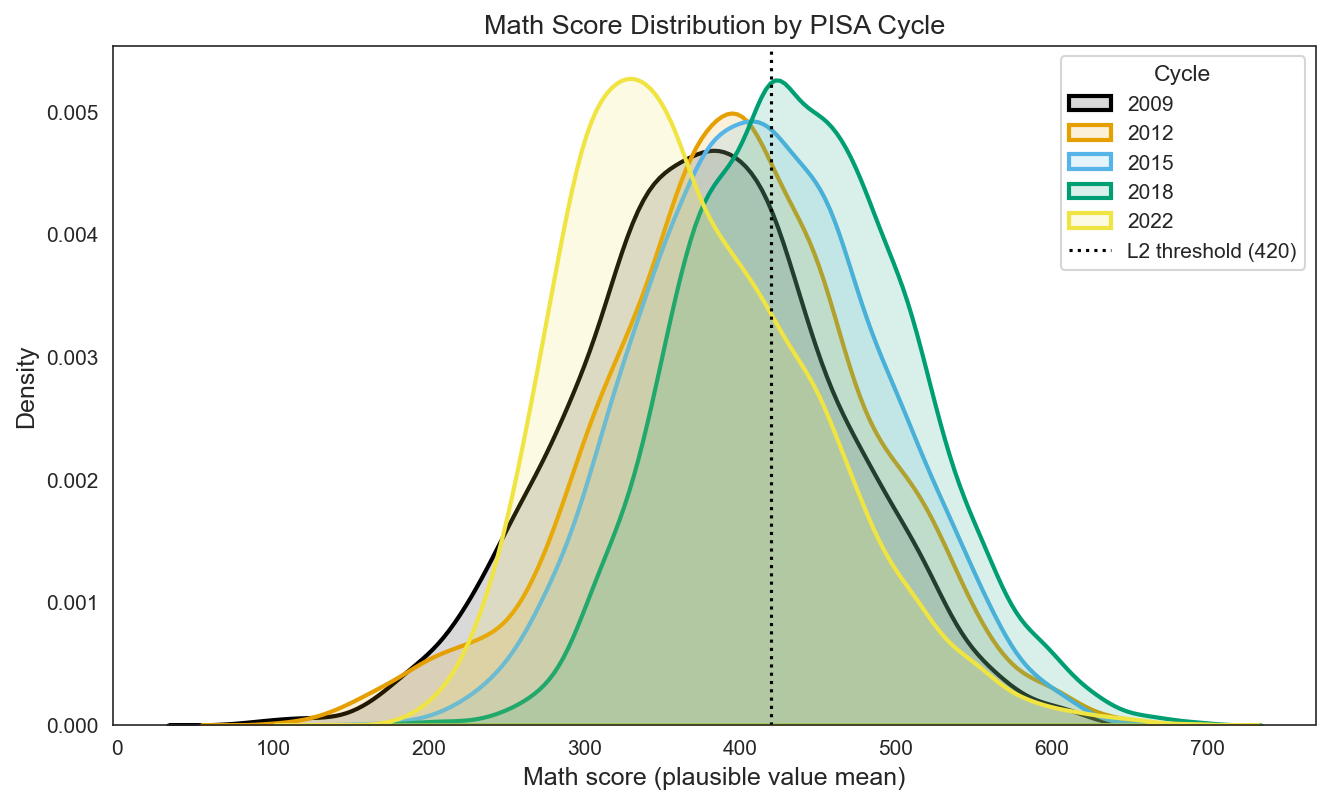

In [8]:
from src.visualization.eda import plot_score_distributions
fig = plot_score_distributions(df); plt.show()

## 3. Feature availability / missingness

Which background indices are present in each cycle? The 2015 column is the Albania-specific gap (OECD did not compute background indices for Albania that cycle).

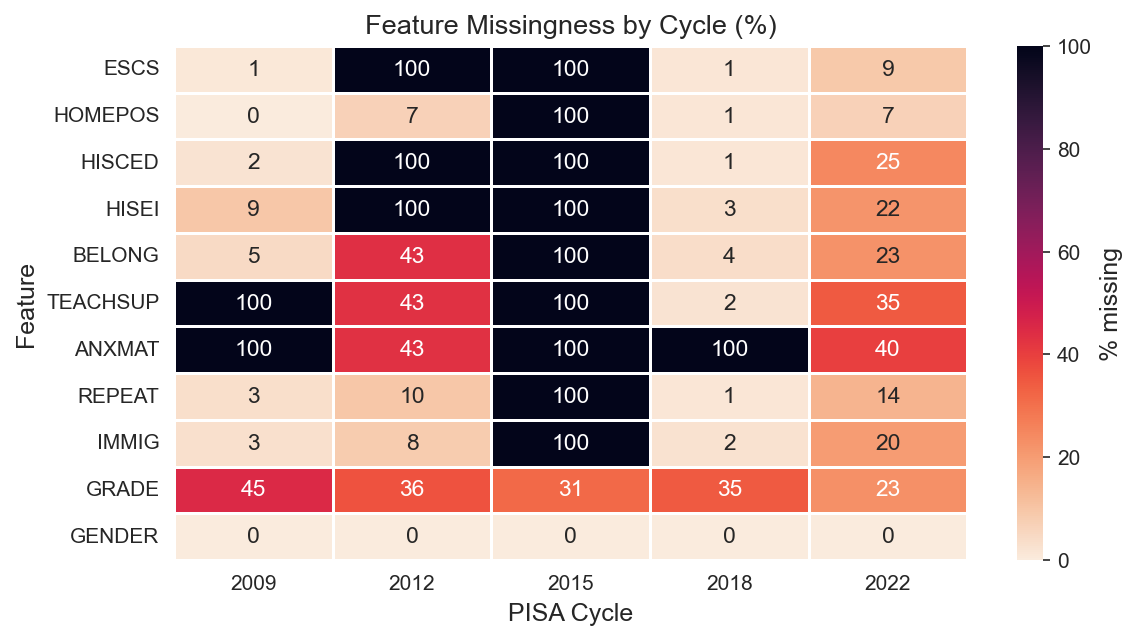

In [9]:
from src.visualization.eda import plot_missingness_heatmap
feats = ['ESCS','HOMEPOS','HISCED','HISEI','BELONG','TEACHSUP','ANXMAT','REPEAT','IMMIG','GRADE','GENDER']
fig = plot_missingness_heatmap(df, feats); plt.show()

## 4. Socioeconomic gradient - SES quintile × at-risk

Weighted low-proficiency rate by HOMEPOS/ESCS quintile across cycles.

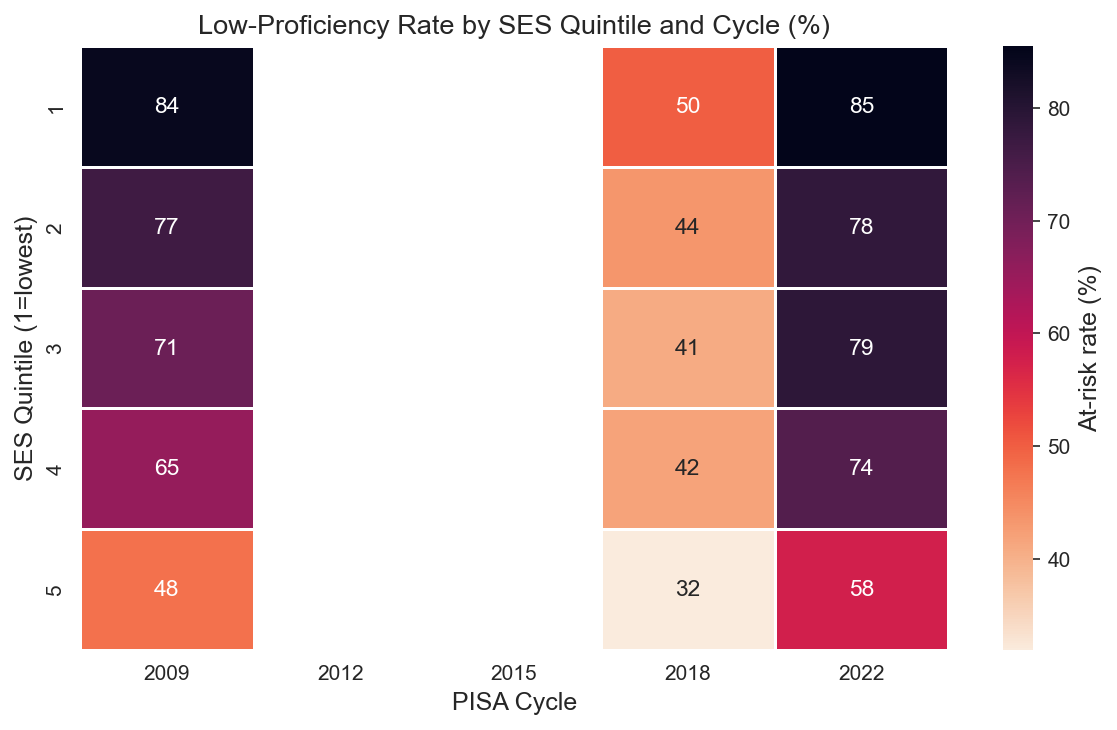

In [10]:
from src.visualization.eda import plot_ses_quintile_heatmap
fig = plot_ses_quintile_heatmap(df); plt.show()

## 4b. The SES gradient as a probability curve

The quintile grid bins SES into five steps; here we show the *continuous* gradient - **P(low proficiency | ESCS)** - as a descriptive weighted-logistic curve, overlaid with the weighted at-risk rate in each SES decile (markers). Comparing **2018 vs 2022** asks whether the crisis merely lifted the whole curve or *steepened* it (hit the disadvantaged harder). This is a single-predictor descriptive gradient, not the multivariable models of notebooks 04/11.

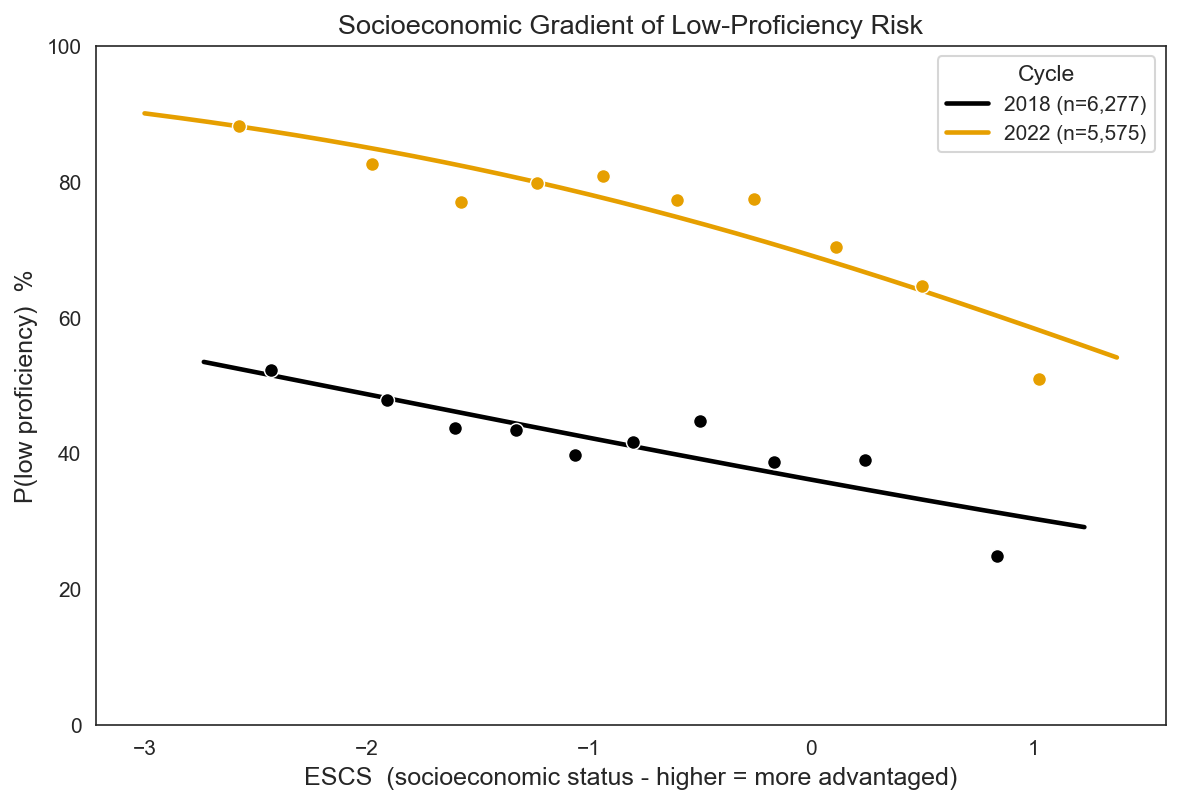

In [11]:
from src.visualization.eda import plot_ses_logistic_curve
fig = plot_ses_logistic_curve(df, cycles=(2018, 2022)); plt.show()

**Reading:** the 2022 curve sits far above 2018 at *every* SES level - the crisis raised risk across the board, not only for the poor. The gradient (slope) persists, so disadvantage still matters, but a pure 'poverty shock' story would predict a steepening the data only partly shows - consistent with the feature-drift result below.

## 5. Feature correlation structure

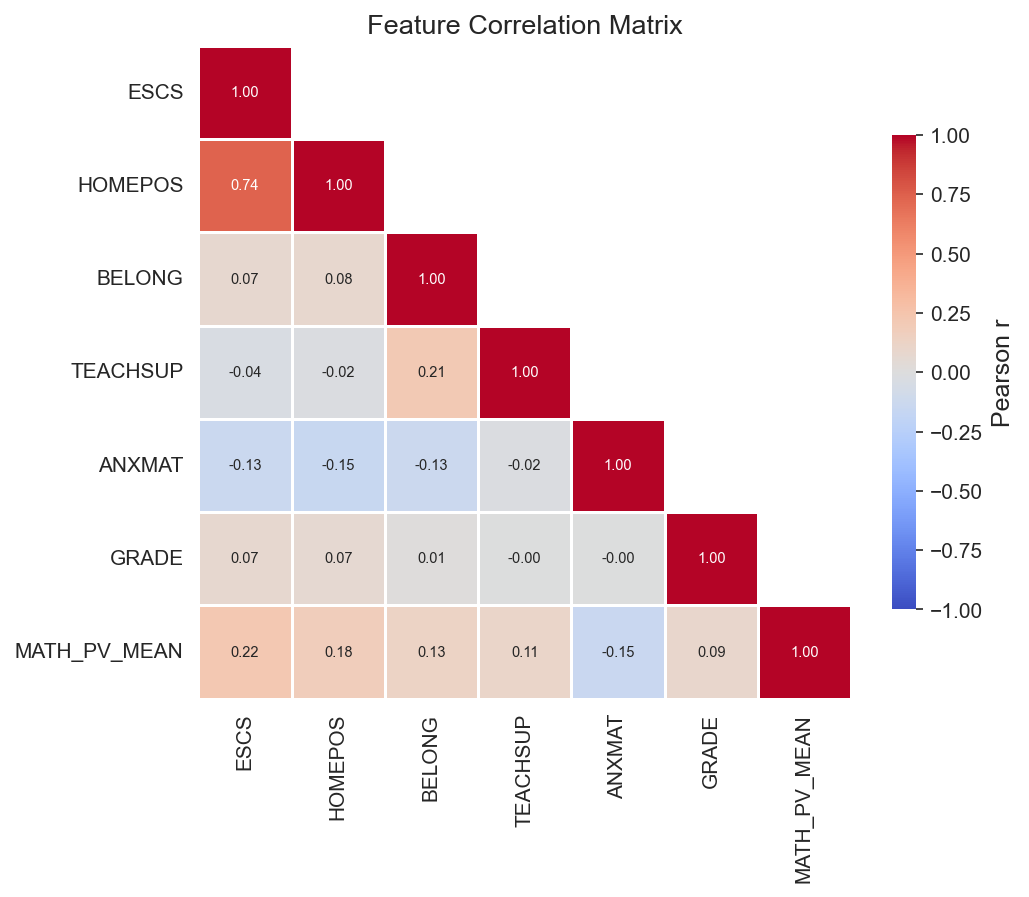

In [12]:
from src.visualization.eda import plot_correlation_matrix
fig = plot_correlation_matrix(df, ['ESCS','HOMEPOS','BELONG','TEACHSUP','ANXMAT','GRADE','MATH_PV_MEAN'])
plt.show()

## 5b. Weighted association tests

All inference uses survey weights. The chi-square uses **normalized** weights (rescaled to the real sample size n) so the statistic isn't inflated by the population scale of `W_FSTUWT`; effect sizes (Cohen's d) are weighted population estimates.

In [13]:
from src.statistics.tests import weighted_chi_square, weighted_cohens_d
d22 = df[df.CYCLE==2022]
chi = weighted_chi_square(d22, 'GENDER', 'AT_RISK_MATH', weight_col='W_FSTUWT')
print('Gender x at-risk (2022):', {k: round(v,4) if isinstance(v,float) else v for k,v in chi.items()})
ar = d22[d22.AT_RISK_MATH==1]; pr = d22[d22.AT_RISK_MATH==0]
dval = weighted_cohens_d(ar['ESCS'], pr['ESCS'], ar['W_FSTUWT'], pr['W_FSTUWT'])
print('Weighted Cohen d (ESCS, at-risk vs proficient):', round(dval,3))

Gender x at-risk (2022): {'chi2': 32.7744, 'p_value': 0.0, 'dof': 1, 'cramers_v': 0.0735, 'n_effective': 6129}
Weighted Cohen d (ESCS, at-risk vs proficient): -0.496


## 5c. Which features separate at-risk students? (effect-size ranking)

The single most decision-relevant table in the EDA: every candidate predictor ranked by the *strength* of its weighted association with low proficiency, not just its significance (with n≈6k almost everything is 'significant'). Numeric features use weighted **Cohen's d** (at-risk vs proficient; sign = direction); categoricals use **Cramer's V** with the chi-square *p*. This is what a feature-importance plot later has to beat.

In [14]:
from src.statistics.tests import feature_effect_sizes
feature_effect_sizes(
    d22,
    numeric_features=['ESCS','HOMEPOS','HISCED','HISEI','BELONG','TEACHSUP','ANXMAT','GRADE'],
    categorical_features=['GENDER','REPEAT','IMMIG'],
)

,feature,type,measure,value,magnitude,p_value
0,HOMEPOS,numeric,cohens_d,-0.504,0.504,NaN
1,ESCS,numeric,cohens_d,-0.496,0.496,NaN
2,ANXMAT,numeric,cohens_d,0.486,0.486,NaN
3,HISEI,numeric,cohens_d,-0.455,0.455,NaN
4,BELONG,numeric,cohens_d,-0.231,0.231,NaN
5,TEACHSUP,numeric,cohens_d,-0.141,0.141,NaN
6,REPEAT,categorical,cramers_v,0.104,0.104,0.0000
7,GENDER,categorical,cramers_v,0.074,0.074,0.0000
8,GRADE,numeric,cohens_d,-0.044,0.044,NaN
9,HISCED,numeric,cohens_d,-0.040,0.040,NaN


**Reading:** HOMEPOS, ESCS and **math anxiety (ANXMAT)** are the strongest separators (|d| ≈ 0.5, medium); parental occupation (HISEI) follows. The demographic categoricals - gender, immigrant status - are *statistically* significant but trivially small (V < 0.1), so risk here is an SES-and-affect story far more than a demographic one. Immigrant status is not even significant (p ≈ 0.16), unusual internationally and worth a sentence in the write-up.

## 6. The 2022 crisis - feature drift (2018 → 2022)

Standardized mean difference (Cohen's d) of each feature between the 2018 baseline and the 2022 crisis cohort. This previews the covariate-shift analysis in notebook 03.

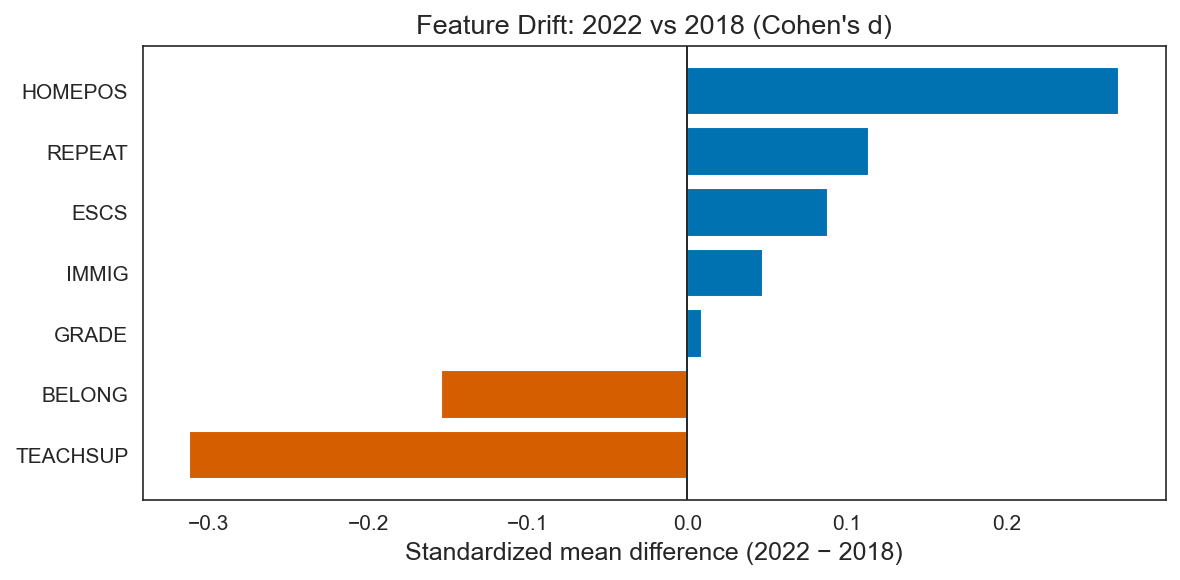

In [15]:
from src.visualization.eda import plot_feature_drift
fig = plot_feature_drift(df, ['ESCS','HOMEPOS','BELONG','TEACHSUP','ANXMAT','GRADE','REPEAT','IMMIG'])
plt.show()

**Takeaway:** Teacher support (TEACHSUP) shows the largest negative drift into 2022, while home possessions (HOMEPOS) shifts positively - the crisis is not a simple SES story.

## Conclusions & Interpretation

- **V-shaped crisis confirmed.** Weighted low-proficiency (math < 420) fell steadily 2009→2018 (**69.3% → 41.9%**), then reversed sharply to **75.3% in 2022** - the worst of all five cycles and the study's central puzzle.
- **Not a pure SES story.** From 2018→2022 `TEACHSUP` shows the largest *negative* drift while `HOMEPOS` drifts *positively*; a simple 'poorer students' narrative does not fit.
- **SES gradient real but partial.** Weighted Cohen's *d* for ESCS (at-risk vs proficient) ≈ **−0.47** (medium); gender × at-risk is significant (χ² *p* < 0.001) but small (Cramér's V ≈ 0.07).
- **Data-availability caveat.** Albania genuinely lacks ESCS in 2012 & 2015 (an OECD gap, not a bug) - longitudinal SES comparisons must skip those cycles.
- **Next:** notebook 03 formalises the 2018→2022 change as *covariate shift*.